Testing out the pattern template matching method for finding replay events
- load in 1 session
- option1: use a single homing as the template
- option2 use the tuning curves as the template
- try to find the homings first
- try to find any other events

Method from Diba and Buzsaki 2007
- define the place fields of the cells
- template is made by using peak firing location
- in times of interest look over a sliding window of 300ms for times when 30% of cells in template fired
- create sequence using the first spiketime of each cell in the 300ms window
- rank order correlation between candidate event and sequence template
- significance testing

In [46]:
%load_ext autoreload
from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.process.process import Process
from JR_test_scripts.escape.escape_utils import load_homing, load_hdir_cells, load_significant_cells
from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip4_21mar
from JR_test_scripts.escape.escape_data_loading_funcs import extract_homing_behave_var

import os
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import pandas as pd
from loguru import logger
import dill as pickle
from pathlib import Path
from scipy.ndimage import gaussian_filter1d
from scipy.stats import zscore
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr, pearsonr
import matplotlib
from skimage.transform import radon
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 20
matplotlib.rcParams['pdf.fonttype'] = 42  # Ensure fonts are embedded in PDF

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
"""Load the data"""
c_names = ['shelter_only', 'barrier', 'flipped_barrier']
conditions = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
explore_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves_explore/")
homie_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
save_path = make_directory("Z:/Jasmine_Laurence/summary_plots/Replay/PreHomingSorted")
tuning_data = '_25bins' # '' or '_50bins' or '_25bins
cond_colors = ['#228B22','#FF8C00','#008B8B']
homing_color = '#6A0DAD'
escape_color = '#E63946'
exp = JAL6_flip4_21mar
session_name = "JAL6_flip4_21mar"
cond = 1

In [ ]:
"""Load tuning data.
We need to identify significant cells and their tuning preference - build the template"""
sig_cells = load_significant_cells(exp, case = "either_tuned", tuning_data = tuning_data)
hdir = load_hdir_cells([exp], [session_name])
sig_cells[hdir,:] = np.full(3, False)

exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'escape'
data = np.load(homie_path + exp_nickname + '_ProperTuning' + tuning_data + '.npz')
sig_escape = data['params_real'][:,:,0] > np.nanpercentile(data['params_shifts'][:,:,:,0], 95, axis = 0)
preferred_tuning = data['params_full'][:,:,1] # preferred %escape for neurons in each condition

template_seq = np.argsort(preferred_tuning[sig_cells[:,cond],cond])

2025-04-24 12:05:41.459 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


In [35]:
"""Load frame by cluster matrix
This should probably be zscored!"""
session = Process(exp).load_session()
base_path = os.path.join(session.base_path, session.processed_path)

# matrix
fcm = np.load(
    os.path.join(session.base_path, session.processed_path)
    + "\\"
    + "frame_by_good_cluster_matrix.npy"
)

# only keep sig cells in this condition
fcm = gaussian_filter1d(fcm[:,sig_cells[:,cond]], 2, axis = 0)

# only keep timepoints in this condition
video_df = pl.read_csv(os.path.join(base_path, "full_video_dataframe.csv"))
bar = video_df["barrier_present"].to_numpy()
barflip = video_df["barrier_flipped"].to_numpy()
y_pos = video_df["mouse_y_position"].to_numpy()
x_pos = video_df["mouse_x_position"].to_numpy()
condition = np.zeros(len(bar))
condition[bar] += 1
condition[barflip] += 1

# select condtion and sort by pref tuning
fcm = fcm[condition == cond,:]
fcm = fcm[:,template_seq]

# zscore neural data
fcm_z = zscore(fcm, axis = 0) # time x neurons

2025-04-24 13:19:09.567 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


In [15]:
"""Load the homing data"""
h_on, h_off, homing_bool = load_homing(session, int(np.amax(np.unique(video_df['frames'].to_numpy()))))

# booleans for homing+escape and explore
# TODO this is a hack into the escapes to remove the 1s of pause before they start running
escape = video_df['EscapePeriod'].to_numpy()
escape_bool = np.full_like(escape, False)
start = np.where(np.diff(escape.astype(int)) == 1)[0]
end = np.where(np.diff(escape.astype(int)) == -1)[0]
for s, e in zip(start, end):
    escape_bool[s+40:e] = True

h_e_bool = (homing_bool | escape_bool) & (video_df['OutofshelterIdx'].to_numpy())
h_e_bool = h_e_bool[condition == cond]

2025-04-24 12:59:51.700 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...


In [19]:
"""Extract %escape homing var to compute occupancy map"""
Nbins = 25
esc_var, c, _ = extract_homing_behave_var(session, 
                                                    y_pos, x_pos, 
                                                    bar, barflip, 
                                                    'escape', 
                                                    h_on, h_off, 
                                                    bins=np.append(np.arange(0,1,1/Nbins), 1+1e-10))

discretized_escape = esc_var[c == cond]

In [ ]:
"""Sliding window search
Over windows of 300ms, search for periods when 30% of cells are active (> 1 zscore?)"""
window_ms = 300
window_samples = int((window_ms/1000)*40)
step = int(.1*40) # step every 100ms
threshold = 2 # zscore threshold
frac_active = .3

identified_window = []
identified_num_active = []
activity = np.full(fcm.shape[0], False)

for i in range(0, fcm.shape[0]-window_samples, step):
    window = fcm_z[i:i+window_samples,:] > threshold
    time_over_t = np.sum(window, axis = 0) # number of timepoints above threshold
    num_active = np.sum(time_over_t > 0) # number of active cells
    # check if 30% of cells are active
    if num_active > (frac_active * window.shape[1]):
        activity[i:i+window_samples] = True
        identified_window.append(i)
        identified_num_active.append(num_active)

# there will be some consecutive windows with overlapping activity
# find consecutive windows, look at which one has the highest fraction of active cells
# only keep the one with the most active cells
# Step 1: Find breaks between consecutive windows
diff_window_time = np.diff(identified_window)
breaks = np.where(diff_window_time > 40)[0]
breaks = np.append(breaks, len(identified_window)-1)  # Add the last index

# Step 2: Process each group of consecutive windows
start_idx = 0
best_windows = []
best_activity = np.full(fcm.shape[0], False)  # Initialize best activity array

for end_idx in breaks:
    # Extract the current group of consecutive windows
    group = identified_window[start_idx:end_idx+1]
    
    if len(group) == 0:
        continue
        
    # Find the window with highest fraction of active cells in this group
    group_fractions = [identified_num_active[a] for win_idx in group for a,x, in enumerate(identified_window) if x == win_idx]
    best_window_idx = start_idx + np.argmax(group_fractions)
    
    # Keep only the best window from this group
    best_windows.append(identified_window[best_window_idx])

    # Update the best activity array
    best_activity[identified_window[best_window_idx]:identified_window[best_window_idx] + window_samples] = True
    
    # Move to the next group
    start_idx = end_idx + 1

# Convert to array for easier handling
best_windows = np.array(best_windows)

In [ ]:
def bayesian_decoder(firing_rate_maps, spike_counts, occupancy_map, time_bin_width, n_time_bins, n_position_bins):
    """
    Implements Bayesian decoding to estimate position from neural activity.

    Args:
        firing_rate_maps (np.ndarray): Shape (n_neurons, n_position_bins).
                                       Average firing rate templates.
        spike_counts (np.ndarray): Shape (n_time_bins, n_neurons).
                                   Spike counts in each time bin.
        occupancy_map (np.ndarray): Shape (n_position_bins,).
                                    Normalized occupancy probability P(x).
        time_bin_width (float): Duration of each time bin (τ) in seconds.

    Returns:
        np.ndarray: Shape (n_time_bins, n_position_bins). Posterior probability P(x|n).
    """

    # Add a small epsilon to firing rates to avoid log(0) or 0^0 issues
    epsilon = 1e-10
    firing_rate_maps = np.maximum(firing_rate_maps, epsilon) # Ensure rates > 0

    # Pre-calculate sum of firing rates over neurons for the exponential term
    sum_fr = np.sum(firing_rate_maps, axis=0) # Shape: (n_position_bins,)

    # Initialize posterior matrix
    posterior = np.zeros((n_time_bins, n_position_bins))

    # Calculate posterior for each time bin
    for t in range(n_time_bins):
        n_t = spike_counts[t, :] # Spike counts for this time bin, shape: (n_neurons,)

        # Calculate log-likelihood for numerical stability
        # log(prod(f_i(x)^n_i)) = sum(n_i * log(f_i(x)))
        log_likelihood_term = np.sum(n_t[:, np.newaxis] * np.log(firing_rate_maps), axis=0)

        # Exponential term: exp(-τ * sum(f_i(x)))
        exp_term = -time_bin_width * sum_fr

        # Combine terms in log space: log(P(x)) + log(Likelihood)
        # log(P(x|n)) ~ log(P(x)) + sum(n_i*log(f_i(x))) - τ*sum(f_i(x))
        log_posterior_unnormalized = np.log(occupancy_map + epsilon) + log_likelihood_term + exp_term

        # Convert back from log space and normalize
        # Subtract max for numerical stability before exponentiating
        posterior_unnormalized = np.exp(log_posterior_unnormalized - np.max(log_posterior_unnormalized))
        norm_factor = np.sum(posterior_unnormalized)

        if norm_factor > 0:
            posterior[t, :] = posterior_unnormalized / norm_factor
        else:
            # If sum is zero (e.g., no spikes and zero rates), assign uniform probability
            posterior[t, :] = 1.0 / n_position_bins

    return posterior

# --- Trajectory Evaluation Functions ---

def calculate_radon_score(posterior_matrix):
    """Calculates the Radon score for trajectory linearity."""
    if np.sum(posterior_matrix) == 0: # Handle empty matrices
        return 0, 0

    theta = np.linspace(0., 180., max(posterior_matrix.shape), endpoint=False)
    sinogram = radon(posterior_matrix, theta=theta, circle=False)

    # Score: Max variance across angles (or max projection sum)
    radon_score = np.max(np.sum(sinogram**2, axis=0))
    best_angle = theta[np.argmax(np.sum(sinogram**2, axis=0))]

    return radon_score, best_angle

def calculate_linear_weighted_correlation(posterior_matrix):
    """Calculates the maximum linear weighted correlation."""
    n_time_bins, n_position_bins = posterior_matrix.shape
    if n_time_bins < 2 or n_position_bins < 2 or np.sum(posterior_matrix) == 0:
        return 0 # Not enough data or empty matrix

    time_indices = np.arange(n_time_bins)
    position_indices = np.arange(n_position_bins)

    # Create meshgrid for calculations
    T, P = np.meshgrid(time_indices, position_indices, indexing='ij')

    # Calculate weighted means
    total_prob = np.sum(posterior_matrix)
    if total_prob == 0: return 0

    mean_t = np.sum(T * posterior_matrix) / total_prob
    mean_p = np.sum(P * posterior_matrix) / total_prob

    # Calculate weighted covariance and variances
    cov_tp = np.sum((T - mean_t) * (P - mean_p) * posterior_matrix) / total_prob
    var_t = np.sum(((T - mean_t)**2) * posterior_matrix) / total_prob
    var_p = np.sum(((P - mean_p)**2) * posterior_matrix) / total_prob

    # Calculate correlation coefficient
    if var_t > 0 and var_p > 0:
        correlation = cov_tp / np.sqrt(var_t * var_p)
    else:
        correlation = 0

    return correlation

# --- Plotting Function ---
def plot_decoded_trajectory(posterior, title="Decoded Position"):
    """Plots the posterior probability matrix."""
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    im = ax.imshow(posterior.T, aspect='auto', origin='lower', interpolation='nearest')
    ax.set_xlabel('Time Bin')
    ax.set_ylabel('Position Bin')
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label='Posterior Probability')
    plt.tight_layout()
    return fig

def calculate_custom_replay_score(posterior, time_bin_width, position_bin_edges, d, V_range, rho_range):
    """
    Calculates the replay score based on the custom Radon-like method.

    Args:
        posterior (np.ndarray): Shape (n_time_bins, n_position_bins).
                                Posterior probability matrix P(x|n).
        time_bin_width (float): Duration (Δt) of each time bin in seconds.
        position_bin_edges (np.ndarray): Shape (n_position_bins + 1,).
                                         Boundaries of position bins (e.g., in cm).
        d (float): Distance threshold (e.g., 15 cm).
        V_range (tuple or list): Range of velocities (V) to test (e.g., [min_V, max_V, n_V_steps]).
                                 Units should be consistent with position/time (e.g., cm/s).
        rho_range (tuple or list): Range of starting positions (ρ) to test (e.g., [min_rho, max_rho, n_rho_steps]).
                                   Units should be consistent with position (e.g., cm).

    Returns:
        tuple: (R_max, V_max, rho_max, R_map)
            R_max (float): The maximum replay score found.
            V_max (float): The velocity corresponding to R_max.
            rho_max (float): The starting position corresponding to R_max.
            R_map (np.ndarray): 2D array of scores R(V, ρ).
    """
    n_time_bins, n_position_bins = posterior.shape
    min_pos_cm = position_bin_edges[0]
    max_pos_cm = position_bin_edges[-1]

    # --- Create grids for V and rho ---
    Vs = np.linspace(V_range[0], V_range[1], int(V_range[2]))
    rhos = np.linspace(rho_range[0], rho_range[1], int(rho_range[2]))

    R_map = np.zeros((len(Vs), len(rhos))) # To store R(V, rho)

    # --- Iterate through parameter space ---
    for i, V in enumerate(Vs):
        for j, rho in enumerate(rhos):
            total_probability_sum = 0.0

            # --- Iterate through time bins ---
            for k in range(n_time_bins):
                predicted_pos_cm = rho + V * k * time_bin_width

                # --- Check if trajectory is off track ---
                if predicted_pos_cm < min_pos_cm or predicted_pos_cm > max_pos_cm:
                    # Use median probability for this time bin
                    median_prob = np.median(posterior[k, :])
                    total_probability_sum += median_prob
                else:
                    # --- Find position bins within distance d ---
                    min_bound_cm = predicted_pos_cm - d
                    max_bound_cm = predicted_pos_cm + d

                    # Find indices of bins that overlap with [min_bound_cm, max_bound_cm]
                    # A bin j overlaps if:
                    # (bin_edges[j] < max_bound_cm) and (bin_edges[j+1] > min_bound_cm)
                    overlapping_bin_indices = np.where(
                        (position_bin_edges[:-1] < max_bound_cm) &
                        (position_bin_edges[1:] > min_bound_cm)
                    )[0]

                    # Ensure indices are within valid range [0, n_position_bins-1]
                    overlapping_bin_indices = overlapping_bin_indices[
                        (overlapping_bin_indices >= 0) & (overlapping_bin_indices < n_position_bins)
                    ]

                    # --- Sum probability within the band ---
                    if len(overlapping_bin_indices) > 0:
                        prob_in_band = np.sum(posterior[k, overlapping_bin_indices])
                        total_probability_sum += prob_in_band
                    # If no bins overlap (shouldn't happen if predicted_pos is on track), add 0

            # --- Calculate average score R for this (V, rho) ---
            if n_time_bins > 0:
                R_map[i, j] = total_probability_sum / n_time_bins

    # --- Find the maximum score and corresponding parameters ---
    if np.any(R_map): # Check if R_map is not all zeros
        max_idx_flat = np.argmax(R_map)
        max_idx_V, max_idx_rho = np.unravel_index(max_idx_flat, R_map.shape)
        R_max = R_map[max_idx_V, max_idx_rho]
        V_max = Vs[max_idx_V]
        rho_max = rhos[max_idx_rho]
    else:
        R_max = 0.0
        V_max = np.nan
        rho_max = np.nan

    return R_max, V_max, rho_max, R_map

Radon Score: 10382.29, Linear Correlation: 0.41, Angle: 0.0°


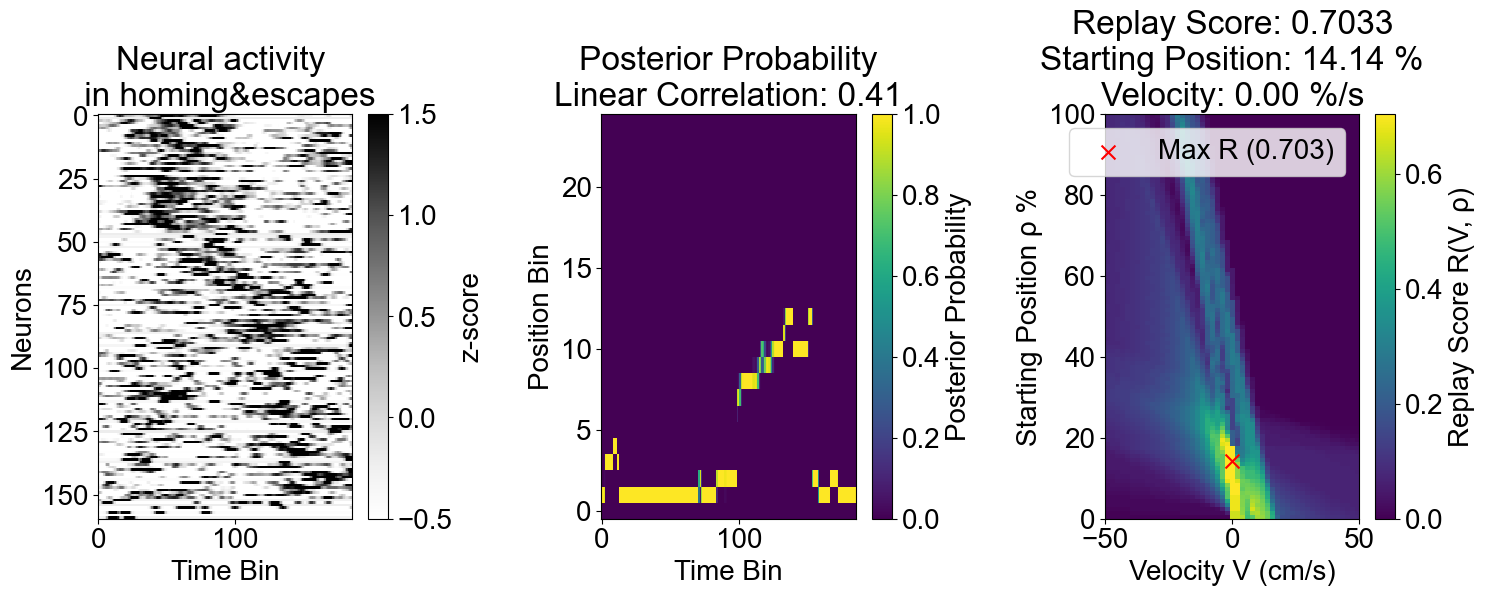

In [ ]:
# firing_rate_maps: A 2D array or list of arrays. Shape: (n_neurons, n_position_bins). Contains the average firing rate of each neuron i for each position bin x. These are the "templates".
# spike_counts: A 2D array. Shape: (n_time_bins, n_neurons). Contains the number of spikes n_i detected for each neuron i within each time bin t of the candidate event.
# occupancy_map: A 1D array. Shape: (n_position_bins,). Contains the normalized probability P(x) of the animal being in each position bin x, derived from overall session behavior.
# time_bin_width (τ): A float. The duration of each time bin in seconds (e.g., 0.02 for 20ms).
# n_neurons (N): An integer. The total number of neurons used for decoding.
# n_position_bins: An integer. The number of spatial bins used to discretize the environment.
# n_time_bins: An integer. The number of time bins in the candidate event window.

# pull out the data
idx = 15
h_start = np.where(np.diff(h_e_bool.astype(int)) > 0)[0][idx]
h_end = np.where(np.diff(h_e_bool.astype(int)) < 0)[0][idx]
firing_rate_maps = data['fr_full'][cond,sig_cells[:,cond],:] # tuning curves for each neuron
firing_rate_maps = firing_rate_maps[template_seq,:] # sort by pref tuning
spike_counts = fcm[h_start:h_end,:]

# set up some variables
n_neurons = fcm.shape[1]
n_position_bins = firing_rate_maps.shape[1]
n_time_bins = spike_counts.shape[0]
time_bin_width = 0.025  # 25 ms for a 40Hz frame rate
# Define position bins (replace with your actual bins)
max_fract = 100
position_bin_edges = np.linspace(0, max_fract, n_position_bins + 1)

# Define parameters
fract_thresh = 10.0 # Threshold of fraction of route in percent

# Define parameter search ranges (adjust based on expected replay speeds/positions)
# Velocity range (e.g., -10 m/s to +10 m/s, 101 steps) -> -1000 cm/s to 1000 cm/s
V_range = [-50, 50, 51]
# Starting position range (e.g., full track length, 100 steps)
rho_range = [0, max_fract, 100]

# Discretize the escape variable
occupancy_counts = np.bincount(discretized_escape.astype(int), minlength=n_position_bins)
occupancy_map = occupancy_counts / np.sum(occupancy_counts)
occupancy_map = np.ones(n_position_bins) / n_position_bins # Uniform prior

posterior = bayesian_decoder(firing_rate_maps, spike_counts, occupancy_map, time_bin_width, n_time_bins, n_position_bins)
radon_score, radon_angle = calculate_radon_score(posterior)
linear_corr = calculate_linear_weighted_correlation(posterior)
R_max, V_max, rho_max, R_map = calculate_custom_replay_score(posterior, time_bin_width, position_bin_edges, fract_thresh, V_range, rho_range)

# Plotting the results
fig, ax = plt.subplots(1, 3, figsize=(15, 6))

im = ax[0].imshow(zscore(spike_counts, axis = 0).T, vmin=-.5, vmax=1.5, aspect = 'auto', cmap = 'Greys', interpolation = 'none')
ax[0].set_xlabel('Time Bin')
ax[0].set_ylabel('Neurons')
ax[0].set_title('Neural activity \n in homing&escapes')
fig.colorbar(im, ax=ax[0], label='z-score')

im = ax[1].imshow(posterior.T, aspect='auto', origin='lower', interpolation='nearest')
ax[1].set_xlabel('Time Bin')
ax[1].set_ylabel('Position Bin')
ax[1].set_title('Posterior Probability' + '\n' + f"Linear Correlation: {linear_corr:.2f}")
fig.colorbar(im, ax=ax[1], label='Posterior Probability')
plt.tight_layout()

im = ax[2].imshow(R_map.T, aspect='auto', origin='lower',
               extent=[V_range[0], V_range[1], rho_range[0], rho_range[1]], cmap='viridis')
fig.colorbar(im, ax=ax[2], label = 'Replay Score R(V, ρ)')
ax[2].scatter([V_max], [rho_max], color='red', marker='x', s=100, label=f'Max R ({R_max:.3f})')
ax[2].set_xlabel('Velocity V (cm/s)')
ax[2].set_ylabel(r'Starting Position ρ %')
ax[2].set_title(f"Replay Score: {R_max:.4f}" + '\n' + f"Starting Position: {rho_max:.2f} %" + '\n' + f"Velocity: {V_max:.2f} %/s")
ax[2].legend()

print(f"Radon Score: {radon_score:.2f}, Linear Correlation: {linear_corr:.2f}, Angle: {radon_angle:.1f}°")